<h1 align="center"><b>Multi-Class Tabular Classification via Feedforward Neural Networks</b></h1>

## **Feedforward Neural Networks using Tabular Data** 

In [13]:
# Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split


[1] Dataset Structure:
  Training  : 41348 samples, 7 columns
  Test      : 7297 samples, 7 columns

Column dtypes:
 neighbourhood_group     object
room_type               object
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object

[2] Missing Values (training set)
neighbourhood_group     839
room_type               611
minimum_nights         1322
amenity_score           916
number_of_reviews      1123
availability_365        595
dtype: int64
  'neighbourhood_group' → mode fill: 'Manhattan'
  'room_type' → mode fill: 'Entire home/apt'
  'minimum_nights' → median fill: 3.0000
  'amenity_score' → median fill: 51.4000
  'number_of_reviews' → median fill: 5.0000
  'availability_365' → median fill: 44.0000

[3] Target Class Distribution
price_class
Budget       5567
Moderate    23287
Premium      9844
Luxury       2650
Name: count, dtype: int64


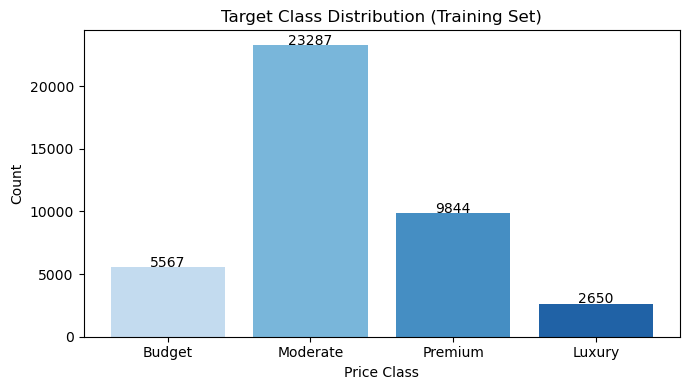


[4] categorical encoding: One-Hot applied to ['neighbourhood_group', 'room_type']

[5] normalisation: z-score (mean=0, std=1) on ['minimum_nights', 'number_of_reviews', 'availability_365', 'amenity_score']


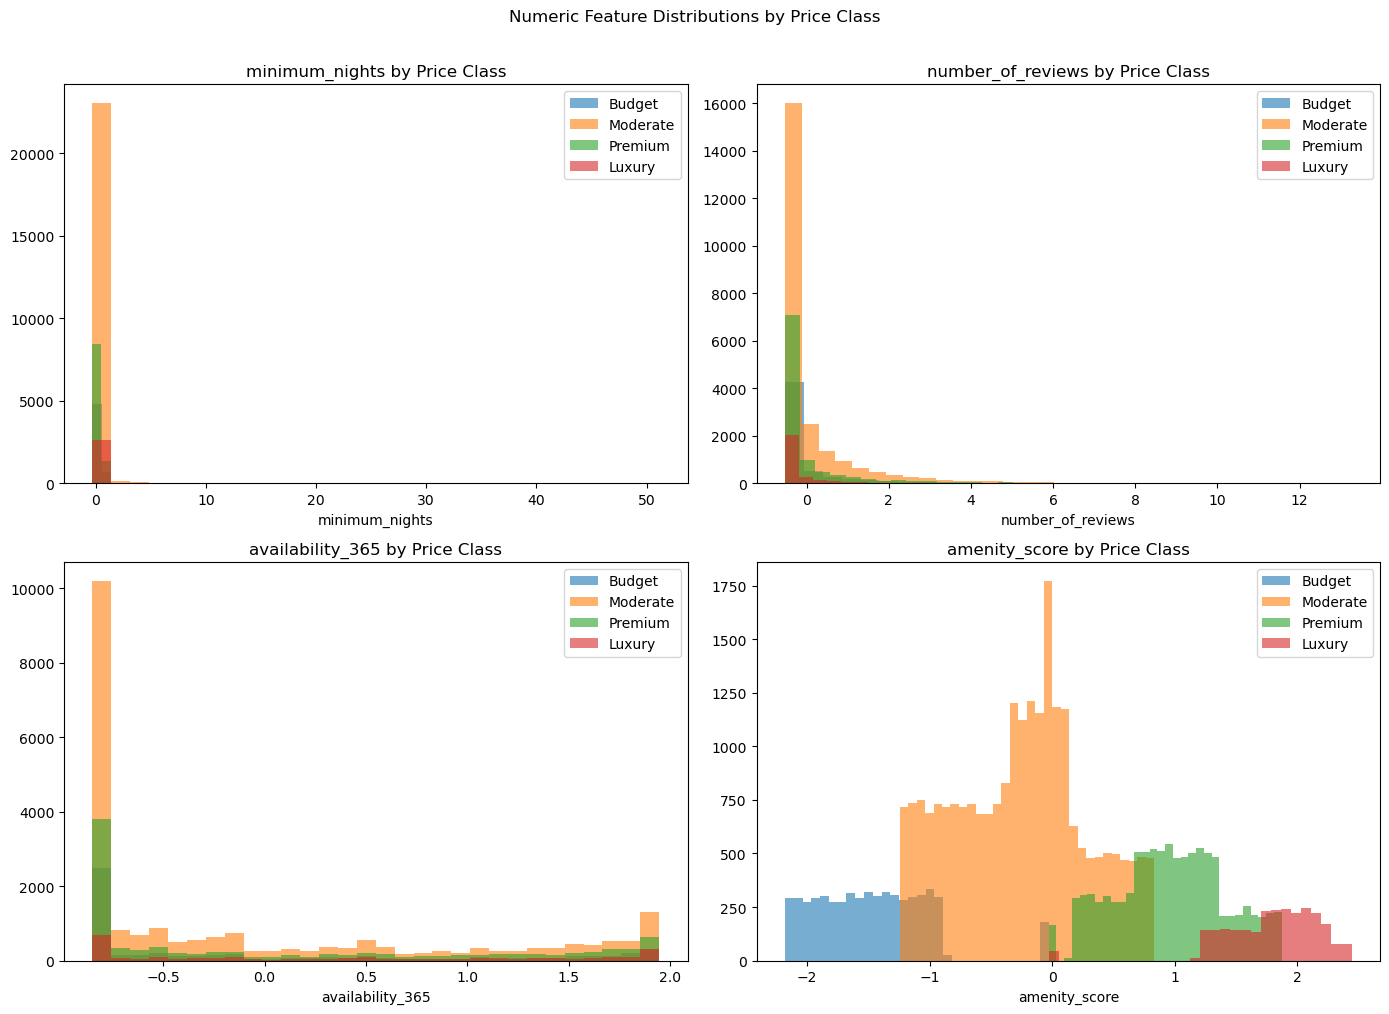

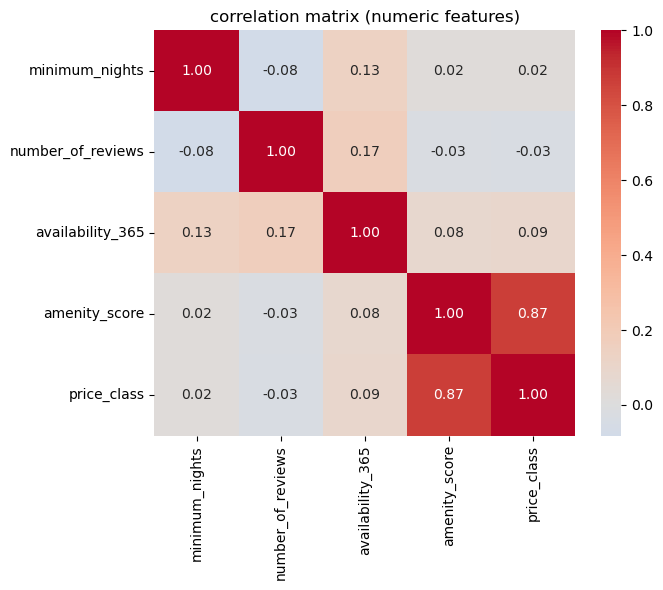

In [27]:
# PART A:  Data Preprocessing and Expolatory Data Analysis (EDA)

def load_and_preprocess(train_path="train.csv", test_path="test.csv"):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    # 1. dataset structure
    print("\n[1] Dataset Structure:")
    print(f"  Training  : {train_df.shape[0]} samples, {train_df.shape[1]} columns")
    print(f"  Test      : {test_df.shape[0]} samples, {test_df.shape[1]} columns")
    print("\nColumn dtypes:\n", train_df.dtypes)

    # 2. missing values 
    print("\n[2] Missing Values (training set)")
    mv = train_df.isnull().sum()
    print(mv[mv > 0] if mv.any() else "  No missing values found.")
  
  
    # Strategy: median imputation for numeric (robust to outliers),
    # mode imputation for categorical (preserves most-common class).
    for col in train_df.columns:
        if train_df[col].isnull().any():
            if train_df[col].dtype == 'object':
                fill = train_df[col].mode()[0]
                print(f"  '{col}' → mode fill: '{fill}'")
            else:
                fill = train_df[col].median()
                print(f"  '{col}' → median fill: {fill:.4f}")
            train_df[col] = train_df[col].fillna(fill)
            test_df[col] = test_df[col].fillna(fill)

    # class distribution 
    print("\n[3] Target Class Distribution")
    label_map = {0: "Budget", 1: "Moderate", 2: "Premium", 3: "Luxury"}
    counts = train_df['price_class'].value_counts().sort_index()
    print(counts.rename(label_map))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([label_map[i] for i in counts.index], counts.values,
           # Light Blue -> Medium -> Dark -> Very Dark Navy
        color = ['#BDD7EE', '#6BAED6', '#3182BD', '#08519C'], alpha = 0.9)
    ax.set_title("Target Class Distribution (Training Set)")
    ax.set_xlabel("Price Class")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, str(v), ha='center', fontsize=10)
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150)
    plt.show()
    
    
    #  4. categorical encoding (One-Hot)
    # one-hot chosen because there is no ordinal relationship between
    # neighbourhood groups or room types.
    cat_cols = ['neighbourhood_group', 'room_type']
    train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=False)
    test_df  = pd.get_dummies(test_df,  columns=cat_cols, drop_first=False)
    # align columns (test may be missing some dummies after get_dummies)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)
    print("\n[4] categorical encoding: One-Hot applied to", cat_cols)

    # 5. normalisation (Z-score / StandardScaler)
    num_cols = ['minimum_nights', 'number_of_reviews',
                'availability_365', 'amenity_score']
    means = train_df[num_cols].mean()
    stds  = train_df[num_cols].std().replace(0, 1)   # avoid /0
    train_df[num_cols] = (train_df[num_cols] - means) / stds
    test_df[num_cols]  = (test_df[num_cols]  - means) / stds
    print("\n[5] normalisation: z-score (mean=0, std=1) on", num_cols)

    # 6. feature vs target visualisations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, col in zip(axes.flatten(), num_cols):
        for cls in sorted(train_df['price_class'].unique()):
            subset = train_df[train_df['price_class'] == cls][col]
            ax.hist(subset, bins=30, alpha=0.6,
                    label=label_map[int(cls)])
        ax.set_title(f"{col} by Price Class")
        ax.set_xlabel(col)
        ax.legend()
    plt.suptitle("Numeric Feature Distributions by Price Class", y=1.01)
    plt.tight_layout()
    plt.savefig("feature_distributions.png", dpi=150)
    plt.show()
    
    # 7. correlation matrix
    corr = train_df[num_cols + ['price_class']].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, ax=ax)
    ax.set_title("correlation matrix (numeric features)")
    plt.tight_layout()
    plt.savefig("correlation_matrix.png", dpi=150)
    plt.show()

    return train_df, test_df



if __name__ == "__main__":
    # Change 'load_and_analyze' to 'load_and_preprocess'
    train_clean, test_clean = load_and_preprocess(
        train_path="train.csv", 
        test_path="test.csv"
    )



In [ ]:


# separate features and targets for Training/Validation
feature_cols = [c for c in train_clean.columns if c != 'price_class']
X_all = train_clean[feature_cols].values.astype(float)
y_all = train_clean['price_class'].values.astype(int)

#. 80/20 stratified Split Stratify=y_all ensures class balance is kept perfect for training/validation 
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 3. Prepare the held-out Test set 
X_test = test_clean[feature_cols].values.astype(float)
y_test = test_clean['price_class'].values.astype(int)

print(f"Data Split Success:")
print(f"  Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Data Split Success:
  Train: (33078, 12) | Val: (8270, 12) | Test: (7297, 12)


In [43]:

# PART B: TWO-LAYER MLP FROM SCRATCH 

class MLP_Scratch:
    def __init__(self, input_dim, hidden_dim, output_dim, activation='sigmoid',
                 lr=0.01, seed=0):
        np.random.seed(seed)
        self.lr         = lr
        self.activation = activation.lower()
        self.output_dim = output_dim

        # xavier / he initialisation
        scale1 = np.sqrt(2.0 / input_dim)  if self.activation == 'relu' \
                 else np.sqrt(1.0 / input_dim)
        scale2 = np.sqrt(2.0 / hidden_dim) if self.activation == 'relu' \
                 else np.sqrt(1.0 / hidden_dim)

        self.W1 = np.random.randn(hidden_dim, input_dim)  * scale1
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = np.random.randn(hidden_dim, hidden_dim) * scale2
        self.b2 = np.zeros((hidden_dim, 1))
        self.W3 = np.random.randn(output_dim, hidden_dim) * np.sqrt(1.0 / hidden_dim)
        self.b3 = np.zeros((output_dim, 1))

        # gradient history for Part B(b)
        self.grad_W1_hist = []
        self.grad_W2_hist = []

    #activation helpers 
    def _act(self, z):
        if self.activation == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
        return np.maximum(0, z)                       # ReLU

    def _act_deriv(self, a, z):
        if self.activation == 'sigmoid':
            return a * (1 - a)
        return (z > 0).astype(np.float64)             # ReLU derivative

    # softmax
    @staticmethod
    def _softmax(z):
        z_shifted = z - z.max(axis=0, keepdims=True)
        e = np.exp(z_shifted)
        return e / e.sum(axis=0, keepdims=True)

    # forward pass 
    def forward(self, X):
        self.z1 = self.W1 @ X  + self.b1          # (h, N)
        self.a1 = self._act(self.z1)
        self.z2 = self.W2 @ self.a1 + self.b2     # (h, N)
        self.a2 = self._act(self.z2)
        self.z3 = self.W3 @ self.a2 + self.b3     # (k, N)
        self.a3 = self._softmax(self.z3)           # (k, N)
        return self.a3

    # cross-entropy loss
    def loss(self, probs, Y_oh):
        
        N = Y_oh.shape[1]
        return -np.sum(Y_oh * np.log(probs + 1e-12)) / N

    # backward pass
    def backward(self, X, Y_oh):
        """
        X    : (d, N)
        Y_oh : (k, N)  one-hot labels
        standard backprop; gradients for all three weight matrices.
        """
        N = X.shape[1]

        # output layer delta
        dZ3 = self.a3 - Y_oh                               # (k, N)
        dW3 = dZ3 @ self.a2.T / N
        db3 = dZ3.mean(axis=1, keepdims=True)

        # hidden layer 2
        dA2 = self.W3.T @ dZ3                              # (h, N)
        dZ2 = dA2 * self._act_deriv(self.a2, self.z2)
        dW2 = dZ2 @ self.a1.T / N
        db2 = dZ2.mean(axis=1, keepdims=True)

        # hidden layer 1
        dA1 = self.W2.T @ dZ2                              # (h, N)
        dZ1 = dA1 * self._act_deriv(self.a1, self.z1)
        dW1 = dZ1 @ X.T / N
        db1 = dZ1.mean(axis=1, keepdims=True)

        # store for Part B(b)
        self.grad_W1_hist.append(np.mean(np.abs(dW1)))
        self.grad_W2_hist.append(np.mean(np.abs(dW2)))

        # store input gradient for Part C
        self.dX = self.W1.T @ dZ1                          # (d, N)

        # vanilla gradient descent update
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    # predict 
    def predict(self, X):
        probs = self.forward(X)
        return probs.argmax(axis=0)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return (preds == y).mean()

    # train loop 
    def train(self, X_train, y_train, X_val, y_val, n_classes,
              n_iters=200, verbose=True):
        N = X_train.shape[0]

        # column-major layout
        Xt = X_train.T          # (d, N)
        Xv = X_val.T

        # one-hot encode
        Y_oh = np.zeros((n_classes, N))
        Y_oh[y_train, np.arange(N)] = 1

        train_accs, val_accs, losses = [], [], []

        for it in range(1, n_iters + 1):
            probs = self.forward(Xt)
            L = self.loss(probs, Y_oh)
            self.backward(Xt, Y_oh)

            tr_acc = self.accuracy(Xt, y_train)
            va_acc = self.accuracy(Xv, y_val)
            train_accs.append(tr_acc);  val_accs.append(va_acc);  losses.append(L)

            if verbose and it % 50 == 0:
                print(f"  iter {it:4d}  loss={L:.4f}  train={tr_acc:.3f}  val={va_acc:.3f}")

        return train_accs, val_accs, losses
    



PART B(a): TWO-LAYER MLP FROM SCRATCH (Sigmoid vs ReLU)

--- Activation: SIGMOID ---
  iter   50  loss=1.0881  train=0.563  val=0.563
  iter  100  loss=1.0573  train=0.563  val=0.563
  iter  150  loss=1.0237  train=0.563  val=0.563
  iter  200  loss=0.9859  train=0.563  val=0.563

  Final Train Accuracy : 0.5632
  Final Val  Accuracy  : 0.5632

--- Activation: RELU ---
  iter   50  loss=0.5314  train=0.788  val=0.779
  iter  100  loss=0.4419  train=0.816  val=0.807
  iter  150  loss=0.4092  train=0.827  val=0.818
  iter  200  loss=0.3941  train=0.831  val=0.822

  Final Train Accuracy : 0.8307
  Final Val  Accuracy  : 0.8221


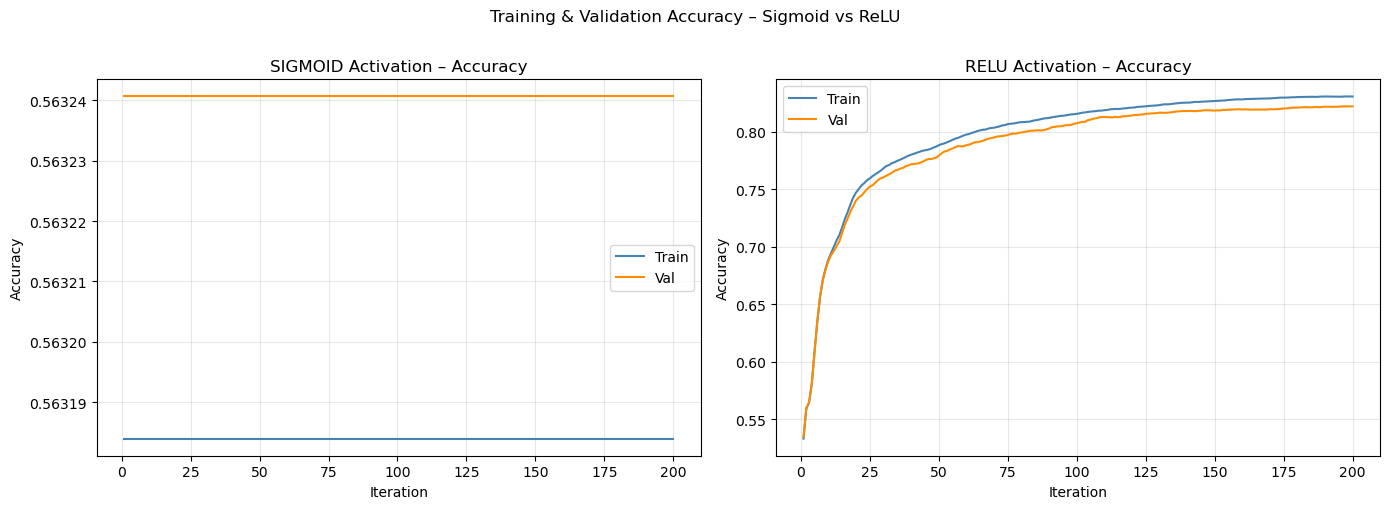


Accuracy plot saved → partB_accuracy.png


In [ ]:

# PART B(a): TRAIN WITH SIGMOID AND RELU, PLOT ACCURACIES

def run_part_b(X_train, y_train, X_val, y_val, n_classes,
               hidden_dim=128, lr=0.05, n_iters=200):
    print("\n" + "=" * 70)
    print("PART B(a): TWO-LAYER MLP FROM SCRATCH (Sigmoid vs ReLU)")
    print("=" * 70)

    results = {}
    for act in ['sigmoid', 'relu']:
        print(f"\n--- Activation: {act.upper()} ---")
        model = MLP_Scratch(
            input_dim=X_train.shape[1],
            hidden_dim=hidden_dim,
            output_dim=n_classes,
            activation=act,
            lr=lr,
            seed=42
        )
        tr_acc, va_acc, losses = model.train(
            X_train, y_train, X_val, y_val,
            n_classes=n_classes, n_iters=n_iters
        )
        results[act] = {'model': model, 'train': tr_acc, 'val': va_acc, 'loss': losses}
        print(f"\n  Final Train Accuracy : {tr_acc[-1]:.4f}")
        print(f"  Final Val  Accuracy  : {va_acc[-1]:.4f}")

    # combined accuracy plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    iters = np.arange(1, n_iters + 1)
    for ax, act in zip(axes, ['sigmoid', 'relu']):
        r = results[act]
        ax.plot(iters, r['train'], label="Train", color='steelblue')
        ax.plot(iters, r['val'],   label="Val",   color='darkorange')
        ax.set_title(f"{act.upper()} Activation – Accuracy")
        ax.set_xlabel("Iteration");  ax.set_ylabel("Accuracy")
        ax.legend();  ax.grid(alpha=0.3)
    plt.suptitle("Training & Validation Accuracy – Sigmoid vs ReLU", y=1.01)
    plt.tight_layout()
    plt.savefig("partB_accuracy.png", dpi=150)
    plt.show()
   

    return results


if __name__ == "__main__":
    results = run_part_b(X_train, y_train, X_val, y_val, n_classes=4)


PART B(b): GRADIENT MAGNITUDE COMPARISON ACROSS LAYERS


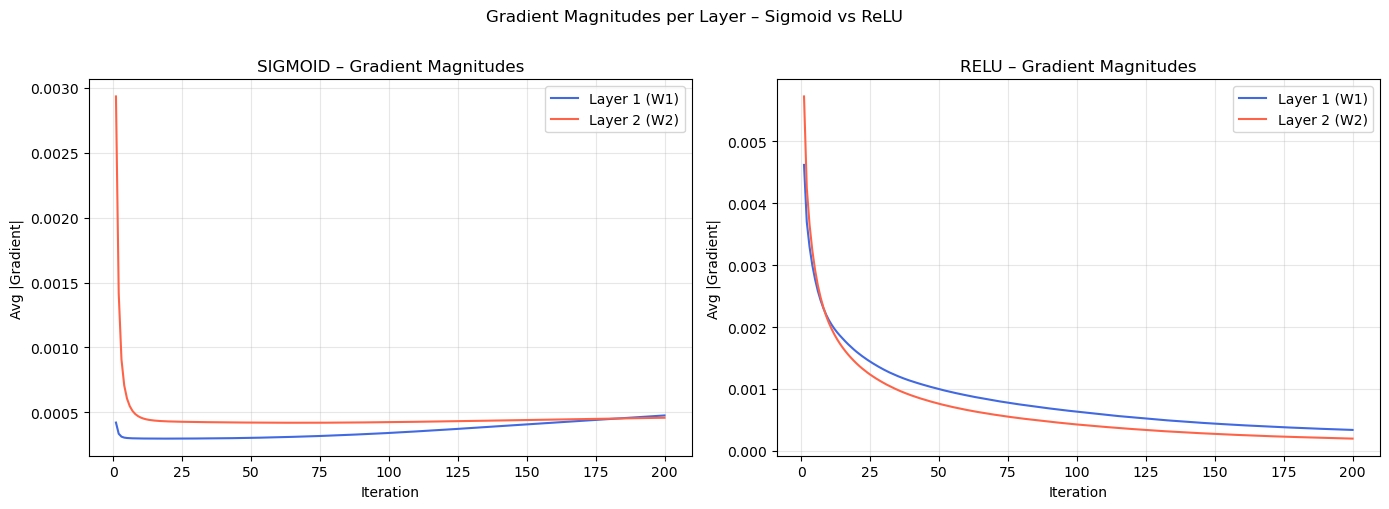

In [ ]:

# PART B(b): GRADIENT MAGNITUDE ACROSS LAYERS
def run_part_b2(results, n_iters=200):
    print("\n" + "=" * 70)
    print("PART B(b): GRADIENT MAGNITUDE COMPARISON ACROSS LAYERS")
    print("=" * 70)

    iters = np.arange(1, n_iters + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, act in zip(axes, ['sigmoid', 'relu']):
        m = results[act]['model']
        ax.plot(iters, m.grad_W1_hist, label="Layer 1 (W1)", color='royalblue')
        ax.plot(iters, m.grad_W2_hist, label="Layer 2 (W2)", color='tomato')
        ax.set_title(f"{act.upper()} – Gradient Magnitudes")
        ax.set_xlabel("Iteration");  ax.set_ylabel("Avg |Gradient|")
        ax.legend();  ax.grid(alpha=0.3)
    plt.suptitle("Gradient Magnitudes per Layer – Sigmoid vs ReLU", y=1.01)
    plt.tight_layout()
    plt.savefig("partB2_gradients.png", dpi=150)
    plt.show()
run_part_b2(results)


PART C(b): PYTORCH MLP + FEATURE ATTRIBUTION

Training PyTorch model …
  Epoch   50  loss=0.5577  train=0.788  val=0.782
  Epoch  100  loss=0.3804  train=0.835  val=0.826
  Epoch  150  loss=0.3595  train=0.837  val=0.827
  Epoch  200  loss=0.3538  train=0.838  val=0.827

-- Gradient-Based Feature Attribution (∂L/∂x) --

  Top-10 most influential features:
     1. amenity_score                        importance=0.00003
     2. room_type_Entire home/apt            importance=0.00001
     3. room_type_Private room               importance=0.00001
     4. neighbourhood_group_Queens           importance=0.00001
     5. neighbourhood_group_Manhattan        importance=0.00001
     6. neighbourhood_group_Bronx            importance=0.00001
     7. neighbourhood_group_Brooklyn         importance=0.00001
     8. neighbourhood_group_Staten Island    importance=0.00001
     9. room_type_Shared room                importance=0.00001
    10. minimum_nights                       importance=0.00000


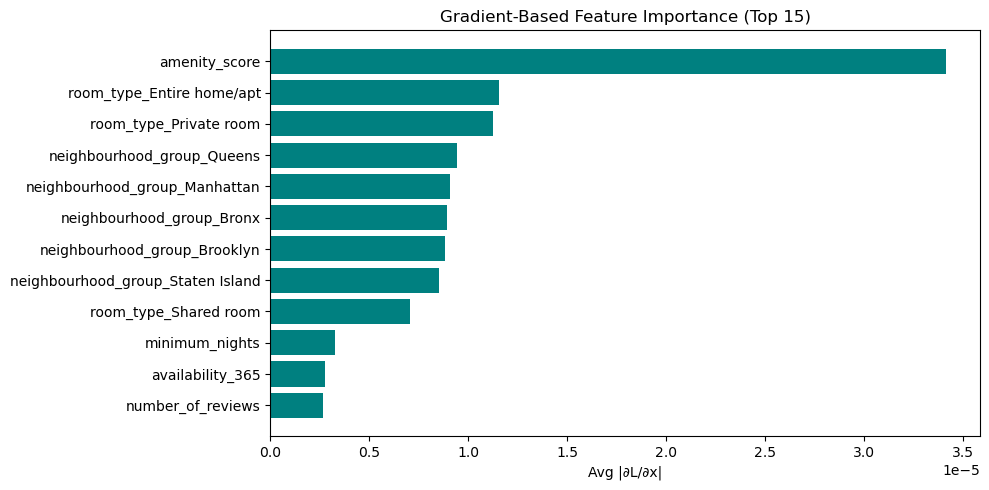


Feature attribution plot saved → partC_feature_attribution.png


In [50]:

# PART C(b): PYTORCH MLP + GRADIENT-BASED FEATURE ATTRIBUTION
LABEL_MAP = {0: "Budget", 1: "Moderate", 2: "Premium", 3: "Luxury"}

def run_part_c(X_train, y_train, X_val, y_val, X_test, y_test,
               n_classes, feature_cols, label_map,
               hidden_dim=128, lr=0.001, epochs=200):
    """
    Re-implements the comparable MLP in PyTorch, trains it, then
    computes gradient-based feature attribution via ∂L/∂x.
    """
    print("\n" + "=" * 70)
    print("PART C(b): PYTORCH MLP + FEATURE ATTRIBUTION")
    print("=" * 70)

    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    

    # build tensors ─
    Xt  = torch.FloatTensor(X_train)
    yt  = torch.LongTensor(y_train)
    Xv  = torch.FloatTensor(X_val)
    yv  = torch.LongTensor(y_val)
    Xte = torch.FloatTensor(X_test)
    yte = torch.LongTensor(y_test)

    # model 
    class TwoHiddenMLP(nn.Module):
        def __init__(self, in_dim, hid_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hid_dim),
                nn.ReLU(),
                nn.Linear(hid_dim, hid_dim),
                nn.ReLU(),
                nn.Linear(hid_dim, out_dim)
            )
        def forward(self, x):
            return self.net(x)

    d = X_train.shape[1]
    model_pt = TwoHiddenMLP(d, hidden_dim, n_classes)
    optim    = torch.optim.Adam(model_pt.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs = [], []

    print("\nTraining PyTorch model …")
    for ep in range(1, epochs + 1):
        model_pt.train()
        optim.zero_grad()
        logits = model_pt(Xt)
        loss   = criterion(logits, yt)
        loss.backward()
        optim.step()

        model_pt.eval()
        with torch.no_grad():
            tr_acc = (model_pt(Xt).argmax(1) == yt).float().mean().item()
            va_acc = (model_pt(Xv).argmax(1) == yv).float().mean().item()
        train_accs.append(tr_acc);  val_accs.append(va_acc)
        if ep % 50 == 0:
            print(f"  Epoch {ep:4d}  loss={loss.item():.4f}  train={tr_acc:.3f}  val={va_acc:.3f}")

    # gradient-based feature attribution 
    print("\n-- Gradient-Based Feature Attribution (∂L/∂x) --")

    model_pt.eval()
    Xt_attr = torch.FloatTensor(X_train).requires_grad_(True)
    logits_attr = model_pt(Xt_attr)
    labels_attr = torch.LongTensor(y_train)
    loss_attr   = criterion(logits_attr, labels_attr)
    loss_attr.backward()

    # average absolute gradient over all training samples, per feature
    grad_x = Xt_attr.grad.detach().numpy()   # (N, d)
    importance = np.abs(grad_x).mean(axis=0) # (d,)

    # ranked list
    ranked_idx  = np.argsort(importance)[::-1]
    print("\n  Top-10 most influential features:")
    for rank, idx in enumerate(ranked_idx[:10], 1):
        fname = feature_cols[idx] if idx < len(feature_cols) else f"feat_{idx}"
        print(f"    {rank:2d}. {fname:<35s}  importance={importance[idx]:.5f}")

    # plot
    top_n = min(15, len(feature_cols))
    top_idx = ranked_idx[:top_n]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh([feature_cols[i] for i in top_idx[::-1]],
            importance[top_idx[::-1]], color='teal')
    ax.set_xlabel("Avg |∂L/∂x|")
    ax.set_title("Gradient-Based Feature Importance (Top 15)")
    plt.tight_layout()
    plt.savefig("partC_feature_attribution.png", dpi=150)
    plt.show()
    print("\nFeature attribution plot saved → partC_feature_attribution.png")

    return model_pt, (train_accs, val_accs, Xte, yte)

model_pt, results_pt = run_part_c(
    X_train, y_train, X_val, y_val, X_test, y_test, 
    n_classes=4, feature_cols=feature_cols, label_map=LABEL_MAP
)


PART D: TEST EVALUATION & GENERALISATION ANALYSIS
  Final Train Accuracy : 0.8383
  Final Val Accuracy   : 0.8268
  Test Accuracy        : 0.3447


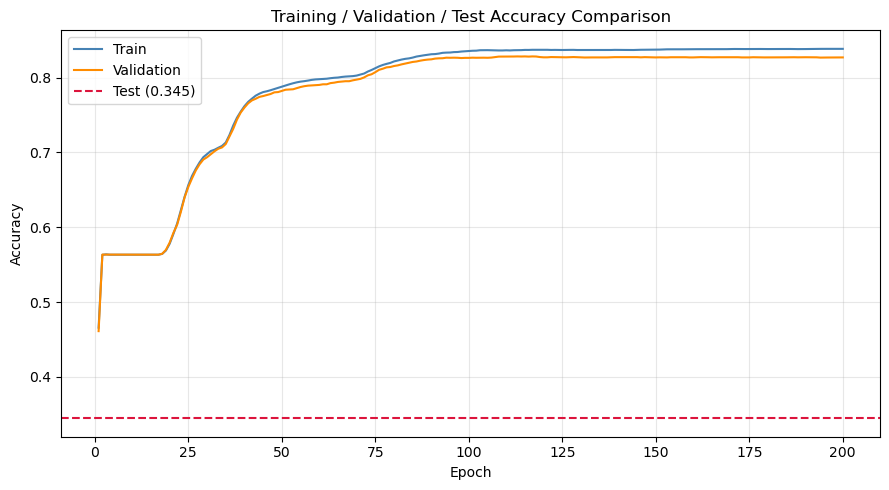

In [52]:

# PART D: TEST EVALUATION & GENERALISATION ANALYSIS

def run_part_d(model_pt, results_pt, n_classes, label_map):
    print("\n" + "=" * 70)
    print("PART D: TEST EVALUATION & GENERALISATION ANALYSIS")
    print("=" * 70)

    import torch
    
    # unpack the results from Part C
    train_accs, val_accs, Xte, yte = results_pt

    # evaluate on Test Data
    model_pt.eval()
    with torch.no_grad():
        logits_te = model_pt(Xte)
        preds_te = logits_te.argmax(1)
    
    test_acc = (preds_te == yte).float().mean().item()

    print(f"  Final Train Accuracy : {train_accs[-1]:.4f}")
    print(f"  Final Val Accuracy   : {val_accs[-1]:.4f}")
    print(f"  Test Accuracy        : {test_acc:.4f}")

    # plotting the generalization Curve
    epochs_range = np.arange(1, len(train_accs) + 1)
    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, train_accs, label="Train", color='steelblue')
    plt.plot(epochs_range, val_accs, label="Validation", color='darkorange')
    plt.axhline(test_acc, linestyle='--', color='crimson', label=f"Test ({test_acc:.3f})")
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training / Validation / Test Accuracy Comparison")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("partD_generalisation.png", dpi=150)
    plt.show()
    
    return test_acc


test_accuracy = run_part_d(model_pt, results_pt, n_classes=4, label_map=LABEL_MAP)

In [53]:
# Check if the average value of your top feature (amenity_score) is similar
print(f"Train amenity mean: {X_train[:, 0].mean():.2f}")
print(f"Test amenity mean: {X_test[:, 0].mean():.2f}")

# Check if feature counts match
print(f"Train features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")

Train amenity mean: 0.00
Test amenity mean: 0.01
Train features: 12
Test features: 12
